# Part 1

In [1]:
import pandas as pd
import numpy as np

# 1) Load the given dataset
df = pd.read_csv(r"D:\Ali\Project Portfolio\ML Projects\Random Forest\ML Project - Random Forest Hotel Cancellation Prediction Analysis.txt")
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01/07/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,02/07/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,02/07/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,03/07/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,06/09/2017
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,07/09/2017
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,07/09/2017
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,07/09/2017


In [2]:
# 2) Print the unique values in all columns
print("--- Unique Values in All Columns ---")
for col in df.columns:
    print(f"{col}: {df[col].unique()[:5]} ... (Total Unique: {df[col].nunique()})")

--- Unique Values in All Columns ---
hotel: ['Resort Hotel' 'City Hotel'] ... (Total Unique: 2)
is_canceled: [0 1] ... (Total Unique: 2)
lead_time: [342 737   7  13  14] ... (Total Unique: 479)
arrival_date_year: [2015 2016 2017] ... (Total Unique: 3)
arrival_date_month: ['July' 'August' 'September' 'October' 'November'] ... (Total Unique: 12)
arrival_date_week_number: [27 28 29 30 31] ... (Total Unique: 53)
arrival_date_day_of_month: [1 2 3 4 5] ... (Total Unique: 31)
stays_in_weekend_nights: [0 1 2 4 3] ... (Total Unique: 17)
stays_in_week_nights: [0 1 2 3 4] ... (Total Unique: 35)
adults: [ 2  1  3  4 40] ... (Total Unique: 14)
children: [ 0.  1.  2. 10.  3.] ... (Total Unique: 5)
babies: [ 0  1  2 10  9] ... (Total Unique: 5)
meal: ['BB' 'FB' 'HB' 'SC' 'Undefined'] ... (Total Unique: 5)
country: ['PRT' 'GBR' 'USA' 'ESP' 'IRL'] ... (Total Unique: 177)
market_segment: ['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Complementary'] ... (Total Unique: 8)
distribution_channel: ['Dire

In [3]:
# 3) Fill nan in agent with mean and "children" with 0
df['agent'] = df['agent'].fillna(df['agent'].mean())
df['children'] = df['children'].fillna(0)

In [4]:
# 4) Fill remaining nan values with ‘other’
df = df.fillna('other')

In [5]:
# 5) Drop all the remaining null values
df.dropna(inplace=True)

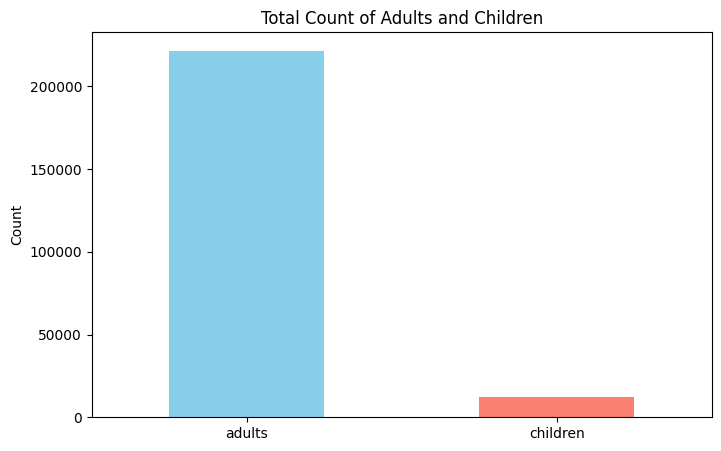

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 6) Plot the count of adult and children with help of a bar plot
# We sum them up to show total counts in a bar plot
total_counts = df[['adults', 'children']].sum()
plt.figure(figsize=(8, 5))
total_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Total Count of Adults and Children')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder

# 7) Perform Label encoding on categorical columns
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Part 2

In [8]:
# 1) Create features and target data (Target: is_canceled)
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

In [9]:
from sklearn.model_selection import train_test_split

# 2) Split into training & testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.ensemble import RandomForestClassifier

# 3) Apply Random forest classifier on data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)

# 4) Create function which show Precision, Recall, Accuracy, Classification Report, and Confusion Matrix
def show_performance_metrics(y_true, y_pred):
    print("\n" + "="*30)
    print("MODEL PERFORMANCE METRICS")
    print("="*30)
    print(f"Accuracy Score:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision Score: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall Score:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:        {f1_score(y_true, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [12]:
# Generate predictions and display metrics
predictions = rf_model.predict(X_test)
show_performance_metrics(y_test, predictions)


MODEL PERFORMANCE METRICS
Accuracy Score:  1.0000
Precision Score: 1.0000
Recall Score:    1.0000
F1 Score:        1.0000

Confusion Matrix:
[[14907     0]
 [    0  8971]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14907
           1       1.00      1.00      1.00      8971

    accuracy                           1.00     23878
   macro avg       1.00      1.00      1.00     23878
weighted avg       1.00      1.00      1.00     23878

